In [5]:
import numpy as np
import matplotlib.pyplot as plt
import math

In [6]:
# ----------------------------------------
# Constantes
# ----------------------------------------
c = 1 # vitesse de propagation du soliton
eps = 0.2
mu = 0.1
x0=0


In [7]:
# ----------------------------------------
# Fonction mathematique sech
# ----------------------------------------
def sech(x):
    return 1 / np.cosh(x)

In [8]:
# ----------------------------------------
# Solution
# ----------------------------------------
# x : position 
# t : temps
def sol_an(x,t,x0):
    xi = x-c*t
    return 3*c/eps * sech(1/2 * math.sqrt(c/mu) * (xi-x0))**2

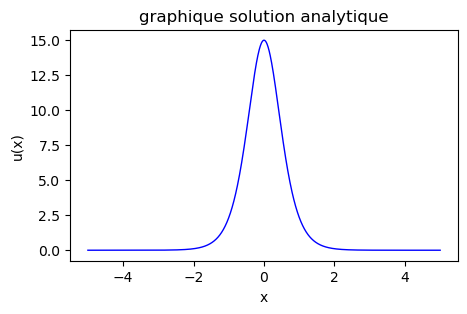

In [9]:
# ----------------------------------------
# Graphique pour la solution analytique
# ----------------------------------------
x = np.linspace(-5, 5, 1000)
u_t0 = sol_an(x, 0, x0)
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(x, u_t0, color='blue', linewidth=1)
ax.set_xlabel("x")
ax.set_ylabel("u(x)")
ax.set_title("graphique solution analytique")
plt.show()

In [ ]:
# ----------------------------------------
# Mise en place du schéma de Crank-Nikolson
# ----------------------------------------
def sol_ck (x_debut,x_fin,Tf,Nx,Nt,eps,mu) :
    #x_debut : point de depart du maillage en x
    #x_fin : point de fin du maillage en x
    #Tf : temps de fin du maillage
    #Nx : nombre de subdivision en X
    #Nt : nombre de subdivision en temps

    t = 0 #temps de début

    #Pas du maillage
    hx = (x_fin - x_debut)/(Nx-1)
    ht = Tf/Nt
    
    #Constantes 
    alpha = (mu * ht) / (hx**3)
    beta = (eps * ht) / hx

    x = np.linspace(x_debut, x_fin, Nx)
    #Creation des matrices / vect
    Un = sol_an(x, 0, x0)
    matA = np.zeros (Nx,Nx)
    MatB = np.zeros (Nx,Nx)


    #Cond. de Dirichlet Un+1 = Un pour i = 0,1 & i = N-1,N
    matA[0,0] = matA[1,1] = 1 
    MatB[0,0] = MatB[1,1] = 1
    matA[Nx-2, Nx-2] = matA[Nx-1, Nx-1] = 1
    MatB[Nx-2, Nx-2] = MatB[Nx-1, Nx-1] = 1
     
    
    for i in range(Nt) : #a chaque temps
        gamma = (alpha / 2) - (beta / 4) * Un

        for j in range(2, Nx - 2):
            matA[j, j-2] = -alpha / 4
            matA[j, j-1] = gamma[j]
            matA[j, j]   = 1
            matA[j, j+1] = -gamma[j]
            matA[j, j+2] = alpha / 4
            
            MatB[j, j-2] = alpha / 4
            MatB[j, j-1] = -gamma[j]
            MatB[j, j]   = 1
            MatB[j, j+1] = gamma[j]
            MatB[j, j+2] = -alpha / 4
            
        # b = B * Un
        b = np.dot(MatB, Un)
        
        # Résolution A * Un+1 = b
        Un1 = np.linalg.solve(matA, b)
        Un = Un1.copy()

    return Un

In [ ]:
# ----------------------------------------
# Graphique Crank-Nikolson
# ----------------------------------------
x_debut = -20
x_fin = 20
Tf = 10
Nx = 300 # On garde Nx raisonnable pour np.linalg.solve
Nt = 1000

print("Calcul matriciel en cours...")
x_num, U_initial, U_numerique_final = sol_df(x_debut, x_fin, Tf, Nx, Nt, eps, mu, c, x0)

# On calcule la vraie solution analytique au temps Tf pour pouvoir comparer
U_analytique_final = sol_an(x_num, Tf, x0)

# Creation du graphique
plt.figure(figsize=(10, 5))

# Tracé de la position de départ (gris pointillé)
plt.plot(x_num, U_initial, '--', color='gray', label='t = 0 (Initiale)')

# Tracé de la simulation numérique (rouge)
plt.plot(x_num, U_numerique_final, label=f'Numérique t = {Tf}', color='red')

# Tracé de la théorie exacte (points bleus) pour vérifier si le schéma est bon
plt.plot(x_num, U_analytique_final, ':', color='blue', linewidth=3, label=f'Analytique t = {Tf}')

plt.xlabel("Position x")
plt.ylabel("Amplitude u(x)")
plt.title("Validation du schéma de Crank-Nicolson sur l'équation de KdV")
plt.legend()
plt.grid(True)
plt.show()